In [2]:
from pathlib import Path

import numpy as np
import torch

from src.pannuke_dataset import PannukePreparedDataset
from models.lit_unet_pannuke import UNetLightning

import ioumatch


In [5]:
NOTEBOOK_DIR = Path.cwd().resolve()

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_ROOT = Path("/run/user/1000/gvfs/smb-share:server=zeus.pasteur.fr,share=bia/ayehadji/projet0") / "data" / "prepared" / "pannuke"

CKPT_DIR = PROJECT_ROOT / "checkpoints"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
ckpts = sorted(CKPT_DIR.glob("unet_pannuke_lit_best.ckpt"))
if not ckpts:
    raise FileNotFoundError(f"Aucun checkpoint trouvé dans {CKPT_DIR}")
ckpt_path = ckpts[-1]
print("Checkpoint chargé :", ckpt_path)

# Charger le modèle Lightning
model = UNetLightning.load_from_checkpoint(ckpt_path)
model = model.to(device)
model.eval()


Checkpoint chargé : /home/bia/PycharmProjects/project0/checkpoints/unet_pannuke_lit_best.ckpt


UNetLightning(
  (model): UNet(
    (down1): DoubleConv(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (down2): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNo

In [7]:
ds_val = PannukePreparedDataset(
    root=DATA_ROOT,
    split="val",
    transform=None,
    return_image_name=False,
)

len(ds_val)


2465

In [9]:
def evaluate_unet_with_ioumatch(
    model,
    dataset,
    device,
    threshold_pred: float = 0.5,
    threshold_iou: float = 0.5,
    max_images: int | None = None,
):
    model.eval()
    f1_scores = []
    tp_total = fp_total = fn_total = 0

    n = len(dataset)
    if max_images is not None:
        n = min(n, max_images)

    for idx in range(n):
        img, mask_inst = dataset[idx]   # img: (3,H,W), mask_inst: (H,W)

        # GT binaire noyau/fond
        gt_bin = (mask_inst.numpy() > 0).astype(np.uint8)

        # Préparation input modèle
        img_batch = img.unsqueeze(0).to(device)  # (1,3,H,W)

        with torch.no_grad():
            logits = model(img_batch)           # (1,1,H,W)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # (H,W)

        pred_bin = (prob > threshold_pred).astype(np.uint8)

        # Évaluation ioumatch sur cette image
        res = ioumatch.evaluate_image(
            pred_bin,
            gt_bin,
            threshold=threshold_iou,
            normalize=True,     # convertit binaires -> labels d'instances
        )

        f1_scores.append(res["f1"])
        tp_total += res["tp"]
        fp_total += res["fp"]
        fn_total += res["fn"]

    f1_scores = np.array(f1_scores)
    global_f1 = 2 * tp_total / (2 * tp_total + fp_total + fn_total + 1e-8)

    return {
        "per_image_f1": f1_scores,
        "mean_f1": float(f1_scores.mean()),
        "std_f1": float(f1_scores.std()),
        "global_tp": int(tp_total),
        "global_fp": int(fp_total),
        "global_fn": int(fn_total),
        "global_f1": float(global_f1),
    }


results = evaluate_unet_with_ioumatch(
    model=model,
    dataset=ds_val,
    device=device,
    threshold_pred=0.5,
    threshold_iou=0.5,
    max_images=10,
)

results


{'per_image_f1': array([1.        , 0.53846154, 0.8       , 0.56      , 0.875     ,
        0.5       , 0.57142857, 0.96774194, 0.8125    , 0.88888889]),
 'mean_f1': 0.751402093426287,
 'std_f1': 0.1806791468535846,
 'global_tp': 86,
 'global_fp': 38,
 'global_fn': 16,
 'global_f1': 0.7610619468689795}

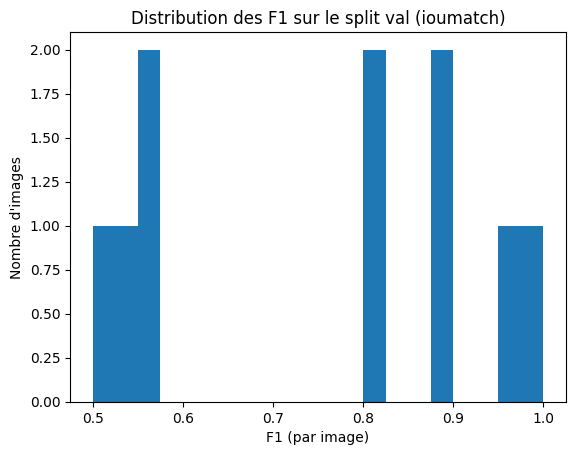

F1 moyen : 0.751402093426287
F1 global: 0.7610619468689795


In [10]:
import matplotlib.pyplot as plt

f1s = results["per_image_f1"]

plt.hist(f1s, bins=20)
plt.xlabel("F1 (par image)")
plt.ylabel("Nombre d'images")
plt.title("Distribution des F1 sur le split val (ioumatch)")
plt.show()

print("F1 moyen :", results["mean_f1"])
print("F1 global:", results["global_f1"])


(array([1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 2., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1.]),
 array([0.5       , 0.51666667, 0.53333333, 0.55      , 0.56666667,
        0.58333333, 0.6       , 0.61666667, 0.63333333, 0.65      ,
        0.66666667, 0.68333333, 0.7       , 0.71666667, 0.73333333,
        0.75      , 0.76666667, 0.78333333, 0.8       , 0.81666667,
        0.83333333, 0.85      , 0.86666667, 0.88333333, 0.9       ,
        0.91666667, 0.93333333, 0.95      , 0.96666667, 0.98333333,
        1.        ]),
 <BarContainer object of 30 artists>)

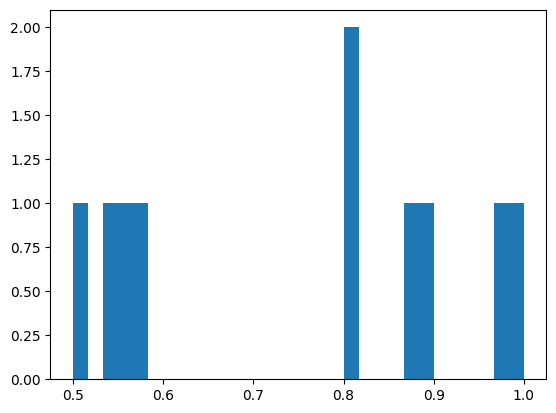

In [11]:
plt.hist(results["per_image_f1"], bins=30)


In [12]:
import pandas as pd

base_dir = Path(
        "/run/user/1000/gvfs/smb-share:server=zeus.pasteur.fr,share=bia/ayehadji/projet0"
    )
prepared_root = base_dir / "data" / "prepared" / "pannuke"

FEATURES_CSV = prepared_root / "pannuke_morphology_features.csv"

df_features = pd.read_csv(FEATURES_CSV)

df_features.head()


,split,image,label,area,perimeter,eccentricity,solidity,circularity,centroid_row,centroid_col
0,train,img_000001.npy,1,831.0,110.669048,0.750877,0.948630,0.852626,24.308063,241.968712
1,train,img_000001.npy,2,2955.0,238.793939,0.767371,0.905608,0.651210,177.234179,40.253469
2,train,img_000001.npy,3,588.0,94.426407,0.827741,0.951456,0.828706,201.634354,184.549320
3,train,img_000001.npy,4,431.0,79.941125,0.733447,0.955654,0.847513,103.904872,206.733179
4,train,img_000001.npy,5,354.0,70.284271,0.762603,0.959350,0.900527,137.793785,169.327684


In [13]:
from skimage.measure import label as sklabel

def bin_to_instances(pred_bin: np.ndarray):
    """
    Convertit un masque binaire 0/1 en labels d’instances (1...N).
    """
    return sklabel(pred_bin.astype(np.uint8))


In [15]:
def get_morphology_map(df, split, image_name):
    """
    Retourne un dict {label_id: morph_class} pour une image donnée.
    """
    dfi = df[(df["split"] == split) & (df["image"] == image_name)]
    return dict(zip(dfi["label"], dfi["morph_class"]))


In [16]:
def evaluate_image_morphology(model, img, mask_inst, morph_map, device):
    """
    img : Tensor (3,H,W)
    mask_inst : Tensor (H,W)
    morph_map : {label_id: morph_class}
    """

    gt_inst = mask_inst.numpy()

    # GT tronqué : certains datasets gardent des valeurs énormes
    gt_inst = gt_inst.astype(np.int32)

    # Step 1 : prédiction
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred_bin = (prob > 0.5).astype(np.uint8)

    # Step 2 : instances prédictes
    pred_inst = bin_to_instances(pred_bin)

    # Step 3 : matching instance <-> instance
    pairs = match_pred_gt(pred_inst, gt_inst)

    # Step 4 : accumulate IoU per morph_class
    per_class = {}

    for p in pairs:
        gt_label = p["gt"]
        iou = p["iou"]

        morph = morph_map.get(gt_label, "unknown")

        if morph not in per_class:
            per_class[morph] = []
        per_class[morph].append(iou)

    return per_class


In [17]:
def evaluate_split_morphology(model, df_features, ds_val, device):
    results = {}  # {morph_class: [iou,...]}

    for img, mask_inst, img_name in PannukePreparedDataset(
        root=DATA_ROOT,
        split="val",
        transform=None,
        return_image_name=True,
    ):

        morph_map = get_morphology_map(df_features, "val", img_name)
        per_class = evaluate_image_morphology(
            model, img, mask_inst, morph_map, device
        )

        for cls, values in per_class.items():
            results.setdefault(cls, []).extend(values)

    return results


In [19]:
df_features.columns.tolist()


['split',
 'image',
 'label',
 'area',
 'perimeter',
 'eccentricity',
 'solidity',
 'circularity',
 'centroid_row',
 'centroid_col']

In [20]:
# Seuil pour très grosses cellules (outliers)
area_q99 = df_features["area"].quantile(0.99)
area_q99

np.float64(2402.0)

In [21]:
def assign_morph(row):
    circ = row["circularity"]
    ecc  = row["eccentricity"]
    sol  = row["solidity"]
    area = row["area"]

    # 1) Rondes : convexes, peu allongées
    if (circ > 0.80) and (ecc < 0.65) and (sol > 0.90):
        return "round"

    # 2) Allongées : noyaux bien elliptiques, assez pleins
    if (ecc > 0.80) and (sol > 0.85):
        return "elongated"

    # 3) Irrégulières : bords bizarres / très grosses
    if (circ < 0.55) or (sol < 0.80) or (area > area_q99):
        return "irregular"

    # 4) Sinon : zone grise
    return "other"

df_features["morph_class"] = df_features.apply(assign_morph, axis=1)


In [22]:
df_features["morph_class"].value_counts()


morph_class
elongated    70637
other        47917
round        39211
irregular     8681
Name: count, dtype: int64

In [24]:
import numpy as np

def extract_pairs_from_iou_matrix(M, threshold=0.5, inclusive=False):
    """
    Construit les paires (pred_id, gt_id, iou) à partir de la matrice IoU de ioumatch.
    """
    if inclusive:
        valid = M >= threshold
    else:
        valid = M > threshold

    pred_ids, gt_ids = np.where(valid)

    # trier par IoU décroissante (greedy)
    order = np.argsort(M[pred_ids, gt_ids])[::-1]

    used_pred = set()
    used_gt = set()
    pairs = []

    for idx in order:
        p = pred_ids[idx]
        g = gt_ids[idx]
        iou = M[p, g]

        if p not in used_pred and g not in used_gt:
            used_pred.add(p)
            used_gt.add(g)
            pairs.append({"pred": int(p), "gt": int(g), "iou": float(iou)})

    return pairs


In [25]:
def match_pred_gt(pred_inst, gt_inst, thr=0.5):
    res = ioumatch.evaluate_image(
        pred_inst,
        gt_inst,
        threshold=thr,
        normalize=False
    )
    M = res["iou_matrix"]

    pairs = extract_pairs_from_iou_matrix(M, threshold=thr)
    return pairs


In [26]:
results = evaluate_split_morphology(
    model=model,
    df_features=df_features,
    ds_val=None,
    device=device
)

for cls, values in results.items():
    values = np.array(values)
    print(f"{cls:12s}  mean={values.mean():.3f}   std={values.std():.3f}   n={len(values)}")


round         mean=0.825   std=0.116   n=9043
elongated     mean=0.812   std=0.117   n=15063
irregular     mean=0.800   std=0.123   n=1725
unknown       mean=0.822   std=0.118   n=1774
other         mean=0.820   std=0.115   n=10687


In [28]:
ds_val[100]

(tensor([[[0.4314, 0.4275, 0.4157,  ..., 0.9059, 0.9412, 0.9373],
          [0.4000, 0.3882, 0.3647,  ..., 0.9098, 0.9490, 0.9373],
          [0.3765, 0.3647, 0.3255,  ..., 0.9098, 0.9490, 0.9373],
          ...,
          [0.4941, 0.5137, 0.5569,  ..., 0.5647, 0.5765, 0.5843],
          [0.5059, 0.5216, 0.5608,  ..., 0.5804, 0.5882, 0.5882],
          [0.5255, 0.5333, 0.5725,  ..., 0.6118, 0.6118, 0.6039]],
 
         [[0.2627, 0.2549, 0.2431,  ..., 0.7333, 0.7686, 0.7686],
          [0.2431, 0.2275, 0.2000,  ..., 0.7294, 0.7725, 0.7647],
          [0.2275, 0.2118, 0.1686,  ..., 0.7255, 0.7686, 0.7569],
          ...,
          [0.3059, 0.3255, 0.3725,  ..., 0.4078, 0.4235, 0.4314],
          [0.3216, 0.3373, 0.3804,  ..., 0.4275, 0.4353, 0.4353],
          [0.3451, 0.3529, 0.3922,  ..., 0.4588, 0.4549, 0.4471]],
 
         [[0.4196, 0.4039, 0.3882,  ..., 0.8235, 0.8588, 0.8588],
          [0.4078, 0.3882, 0.3569,  ..., 0.8196, 0.8627, 0.8549],
          [0.4039, 0.3843, 0.3373,  ...,

In [34]:
from src.pannuke_dataset import PannukePreparedDataset

ds_val = PannukePreparedDataset(
    root=DATA_ROOT,
    split="train",
    transform=None,           # on veut les masques bruts d'instances
    return_image_name=True,
)

len(ds_val)

2620

Text(0.5, 1.0, 'Pred')

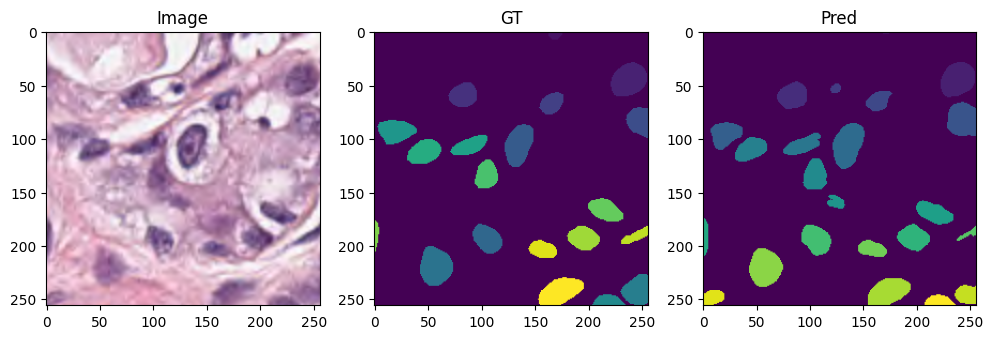

In [35]:
idx = 100
img, mask_gt, name = ds_val[idx]

# prédiction
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(logits)[0,0].cpu().numpy()
pred_bin = (pred > 0.5).astype(np.uint8)
pred_inst = sklabel(pred_bin)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image")
plt.subplot(1,3,2); plt.imshow(mask_gt); plt.title("GT")
plt.subplot(1,3,3); plt.imshow(pred_inst); plt.title("Pred")
